In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/walmart/Walmart.csv


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
df=pd.read_csv('/kaggle/input/walmart/Walmart.csv')

In [5]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
df.shape

(6435, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [9]:
df_group=df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).reset_index()

<AxesSubplot: xlabel='Store', ylabel='Weekly_Sales'>

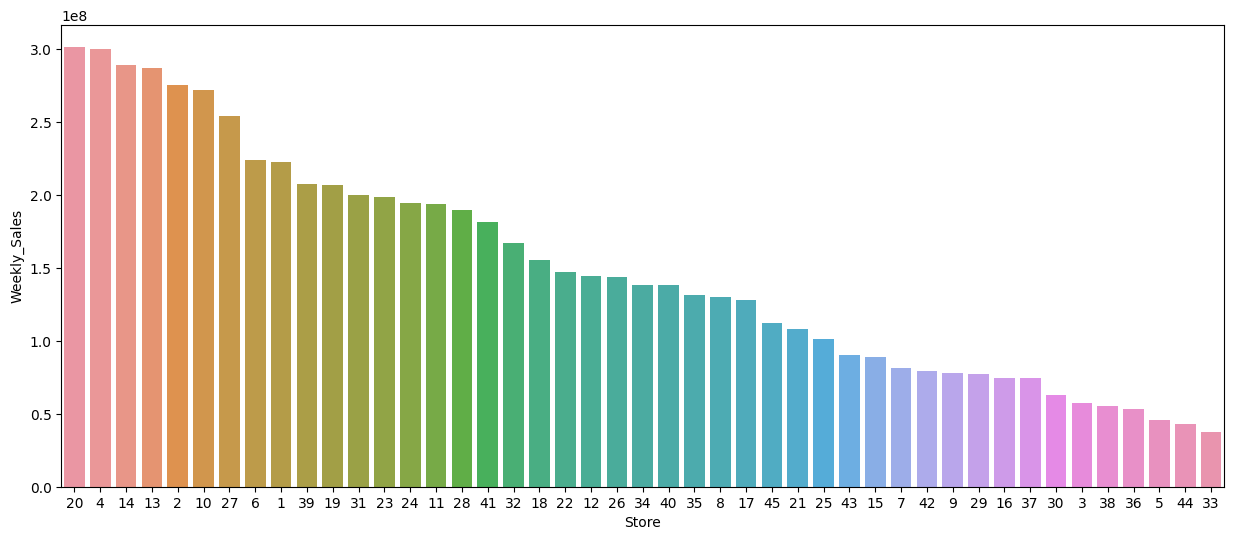

In [10]:
plt.figure(figsize=(15,6))
sns.barplot(x='Store',y='Weekly_Sales',data=df_group,order=df_group.sort_values('Weekly_Sales',ascending=False).Store)

In [11]:
from datetime import datetime

In [12]:
df['Date']=pd.to_datetime(df['Date'])

In [13]:
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [14]:
df_copy=df.copy()

In [15]:
df_copy['Month']=df_copy['Date'].dt.month
df_copy['Year']=df_copy['Date'].dt.year

In [16]:
df_gp_month=df_copy.groupby('Month')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()

<AxesSubplot: xlabel='Month', ylabel='Weekly_Sales'>

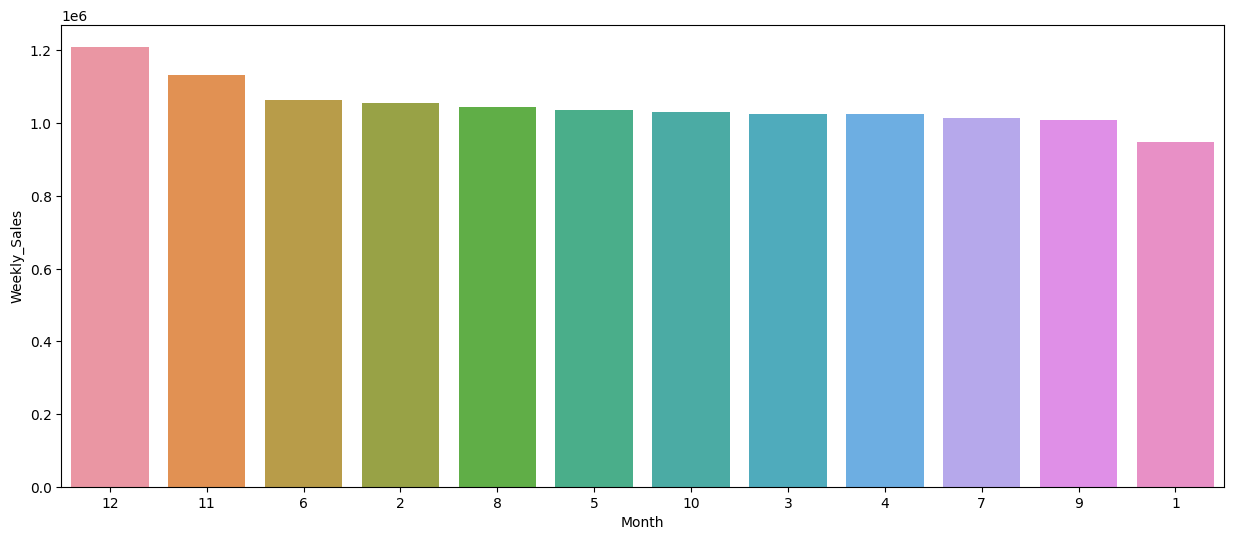

In [17]:
plt.figure(figsize=(15,6))
sns.barplot(x='Month',y='Weekly_Sales',data=df_gp_month,order=df_gp_month.sort_values('Weekly_Sales',ascending=False).Month)

In [18]:
df_gp_year=df_copy.groupby('Year')['Weekly_Sales'].sum().sort_values(ascending=False).reset_index()

<AxesSubplot: xlabel='Year', ylabel='Weekly_Sales'>

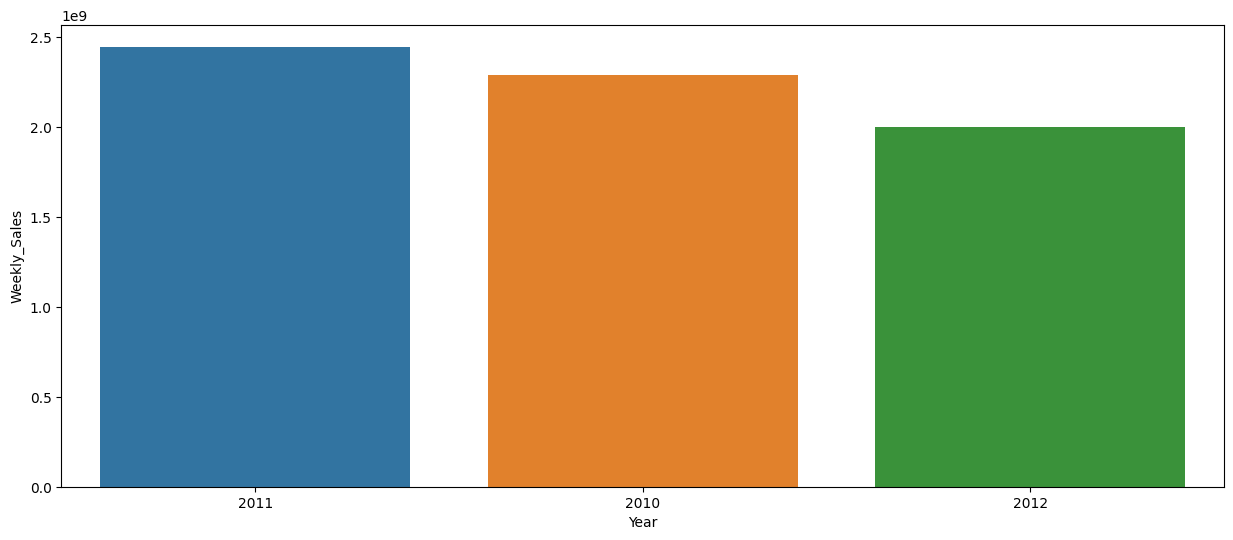

In [19]:
plt.figure(figsize=(15,6))
sns.barplot(x='Year',y='Weekly_Sales',data=df_gp_year,order=df_gp_year.sort_values('Weekly_Sales',ascending=False).Year)

In [20]:
df_group_holi=df_copy.groupby('Holiday_Flag')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()

<AxesSubplot: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

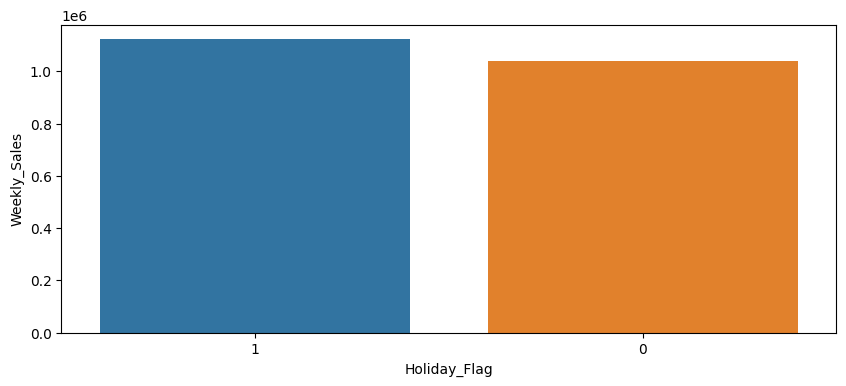

In [21]:
plt.figure(figsize=(10,4))
sns.barplot(x='Holiday_Flag',y='Weekly_Sales',data=df_group_holi,order=df_group_holi.sort_values('Weekly_Sales',ascending=False).Holiday_Flag)

In [22]:
df_copy['week']=df_copy['Date'].dt.week

In [24]:
df.corr()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


In [25]:
def get_store_df(data,data_field,field_value):
    return(data[data[data_field]==field_value])

In [26]:
store_corr=pd.DataFrame(index=['Store','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment'])
for i in range(1,46):
    store_df=get_store_df(df,'Store',i)
    store_corr['Store'+str(i)]=store_df.corr()['Weekly_Sales'].tolist()

In [27]:
store_corr=store_corr.dropna()
store_corrT=store_corr.T
del store_corrT['Weekly_Sales']
store_corrT

,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store1,0.194905,-0.222701,0.124592,0.225408,-0.097955
Store2,0.177726,-0.297673,-0.196375,-0.062431,0.066325
Store3,0.208556,-0.377524,0.140886,0.317250,-0.230413
Store4,0.153388,-0.225583,0.211549,0.351157,-0.337015
Store5,0.302525,-0.175517,0.167352,0.308261,-0.207043
Store6,0.150424,-0.084863,-0.103356,-0.011357,0.044251
Store7,0.248766,0.015077,0.110356,0.289044,-0.165382
Store8,0.172383,-0.312324,0.029752,0.120255,-0.052580
Store9,0.179264,-0.208343,0.205404,0.294805,-0.191534
Store10,0.195119,-0.432569,-0.185058,-0.115374,0.131908


In [28]:
store_list=list(set(df['Store']))
print(store_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


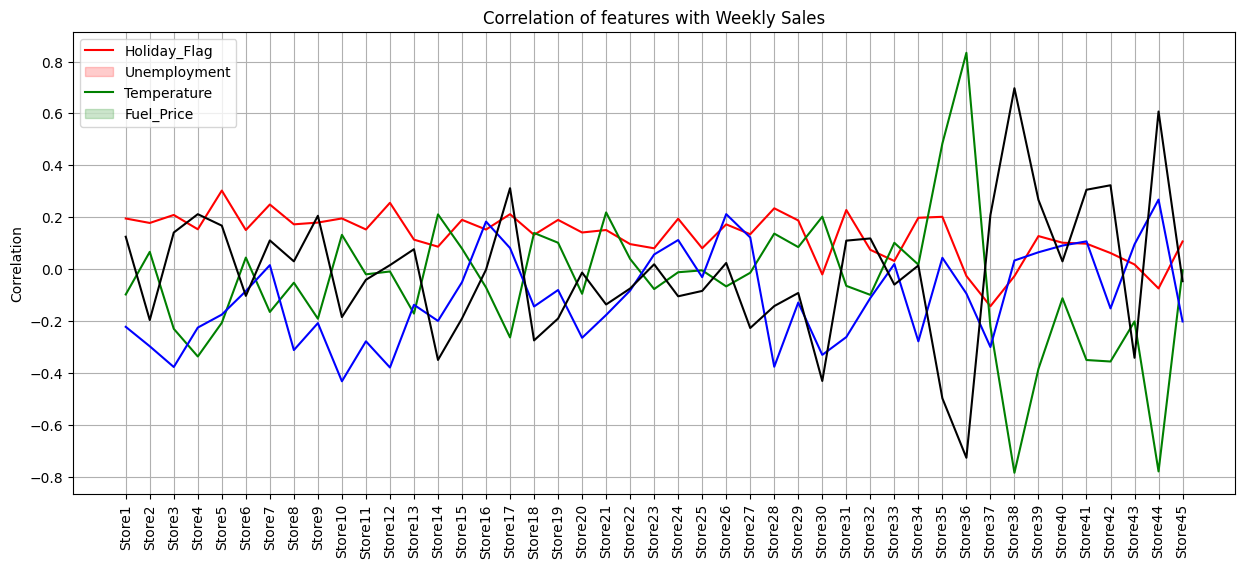

In [29]:
fig,axes=plt.subplots(figsize=(15,6))
plt.xticks(rotation=90)
sns.lineplot(x=store_corrT.index,y=store_corrT.Holiday_Flag,color='red')
sns.lineplot(x=store_corrT.index,y=store_corrT.Unemployment,color='green')
sns.lineplot(x=store_corrT.index,y=store_corrT.Temperature,color='blue')
sns.lineplot(x=store_corrT.index,y=store_corrT.Fuel_Price,color='black')
plt.legend(['Holiday_Flag','Unemployment','Temperature','Fuel_Price'],loc='best')
plt.grid(True)
plt.ylabel("Correlation")
plt.title("Correlation of features with Weekly Sales")
plt.show()

In [30]:
pos_U_corr=store_corrT[store_corrT['Unemployment']>0].sort_values(by='Unemployment')
neg_U_corr=store_corrT[store_corrT['Unemployment']<0].sort_values(by='Unemployment')

In [31]:
print(f"\nThere are{pos_U_corr['Unemployment'].shape[0]} stores whose sales will increase as Unemployment increases")
print(f"\n{pos_U_corr['Unemployment']}")


There are16 stores whose sales will increase as Unemployment increases

Store34    0.017010
Store22    0.039043
Store6     0.044251
Store2     0.066325
Store15    0.078905
Store29    0.084682
Store33    0.101175
Store19    0.101464
Store10    0.131908
Store28    0.136671
Store18    0.139179
Store30    0.201862
Store14    0.210786
Store21    0.218367
Store35    0.483865
Store36    0.833734
Name: Unemployment, dtype: float64


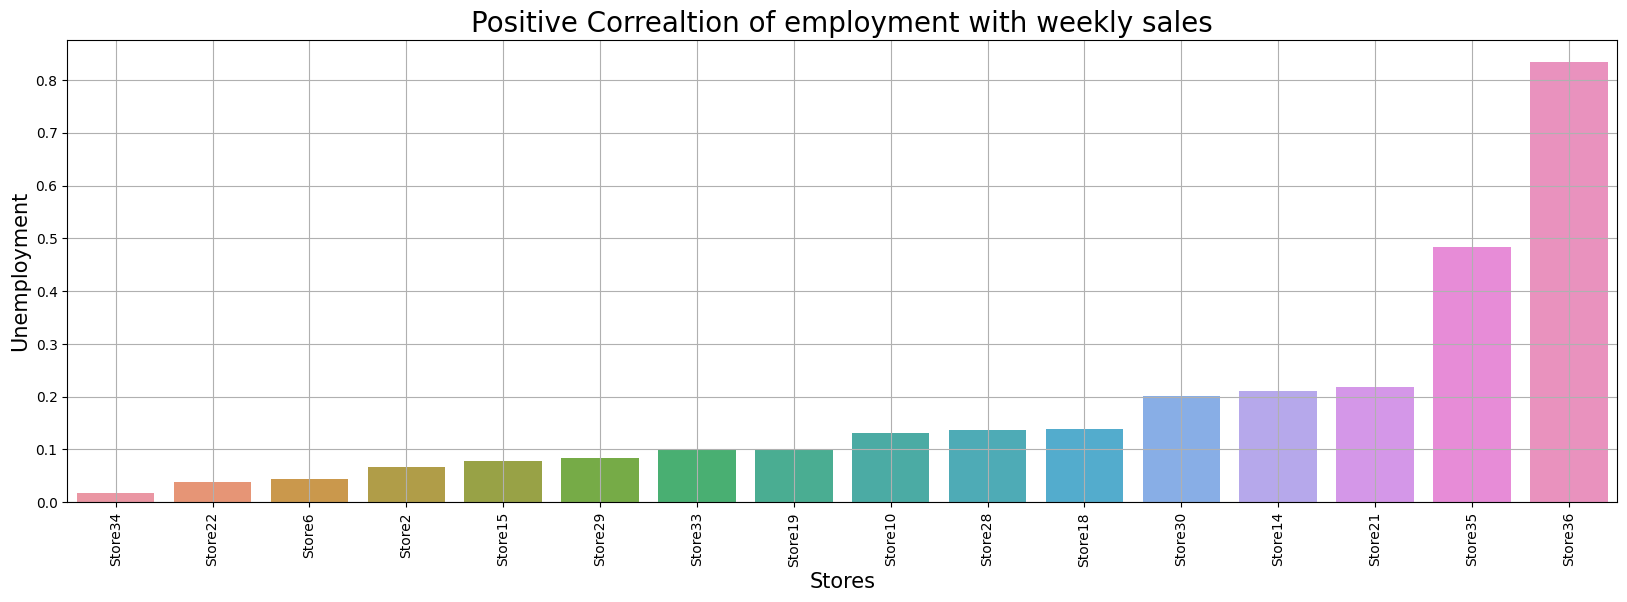

In [32]:
fig,axes=plt.subplots(figsize=(20,6))
plt.xticks(rotation=90)
sns.barplot(x=pos_U_corr.index,y=pos_U_corr.Unemployment)
plt.xlabel("Stores",fontsize=15)
plt.ylabel('Unemployment',fontsize=15)
plt.title("Positive Correaltion of employment with weekly sales",fontsize=20)
plt.grid(True)

In [33]:
print(f"\nThere are{neg_U_corr['Unemployment'].shape[0]} stores whose sales will decrease as Unemployment increases")
print(f"\n{neg_U_corr['Unemployment']}")


There are29 stores whose sales will decrease as Unemployment increases

Store38   -0.785290
Store44   -0.780076
Store39   -0.384681
Store42   -0.356355
Store41   -0.350630
Store4    -0.337015
Store17   -0.263600
Store3    -0.230413
Store37   -0.221287
Store5    -0.207043
Store43   -0.201954
Store9    -0.191534
Store13   -0.171633
Store7    -0.165382
Store40   -0.112528
Store32   -0.099455
Store1    -0.097955
Store20   -0.095341
Store23   -0.077169
Store16   -0.070864
Store26   -0.066899
Store31   -0.064738
Store8    -0.052580
Store11   -0.020339
Store27   -0.014275
Store24   -0.012261
Store12   -0.009286
Store25   -0.004958
Store45   -0.004041
Name: Unemployment, dtype: float64


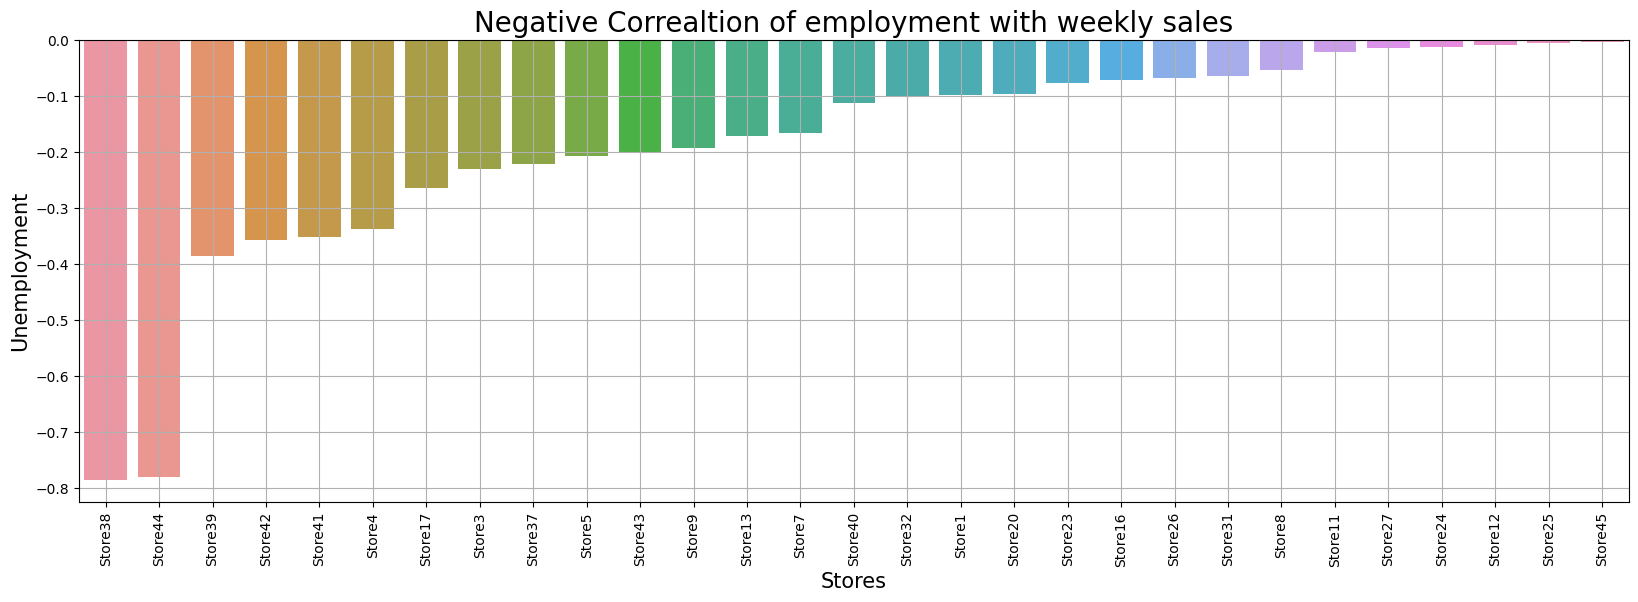

In [34]:
fig,axes=plt.subplots(figsize=(20,6))
plt.xticks(rotation=90)
sns.barplot(x=neg_U_corr.index,y=neg_U_corr.Unemployment)
plt.xlabel("Stores",fontsize=15)
plt.ylabel('Unemployment',fontsize=15)
plt.title("Negative Correaltion of employment with weekly sales",fontsize=20)
plt.grid(True)

In [35]:
Uemp_1=pd.DataFrame(zip(pos_U_corr.index,pos_U_corr.Unemployment),columns=['Stores(pos)','Corr(pos)'])
Uemp_2=pd.DataFrame(zip(neg_U_corr.index,neg_U_corr.Unemployment),columns=['Stores(neg)','Corr(neg)'])
unemp=pd.concat([Uemp_2,Uemp_1],axis=1,join='outer',ignore_index=True)
unemp.columns=['Stores(neg)','Corr(neg)','Stores(pos)','Corr(pos)']
unemp

,Stores(neg),Corr(neg),Stores(pos),Corr(pos)
0,Store38,-0.785290,Store34,0.017010
1,Store44,-0.780076,Store22,0.039043
2,Store39,-0.384681,Store6,0.044251
3,Store42,-0.356355,Store2,0.066325
4,Store41,-0.350630,Store15,0.078905
5,Store4,-0.337015,Store29,0.084682
6,Store17,-0.263600,Store33,0.101175
7,Store3,-0.230413,Store19,0.101464
8,Store37,-0.221287,Store10,0.131908
9,Store5,-0.207043,Store28,0.136671


In [36]:
Store_list=df_group['Store'].tolist()
highest_10=df_group['Store'].head(10).tolist()

In [37]:
print(highest_10)

[20, 4, 14, 13, 2, 10, 27, 6, 1, 39]


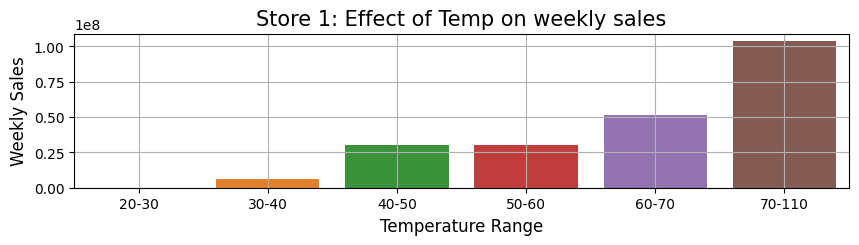

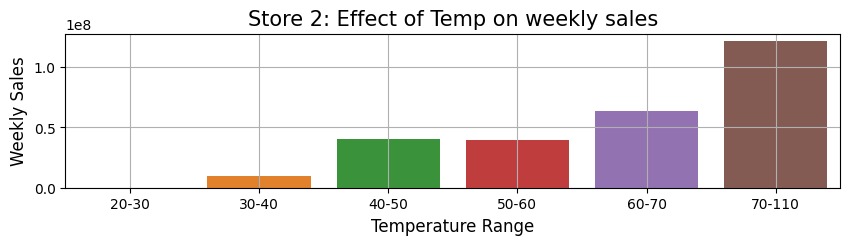

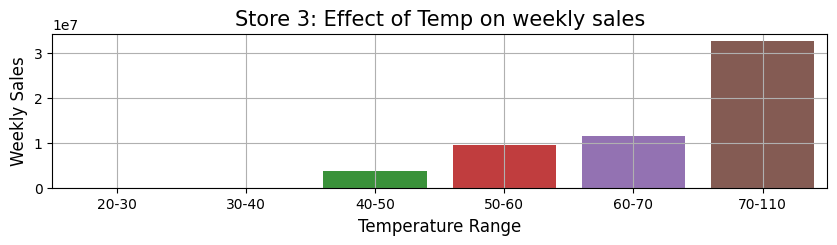

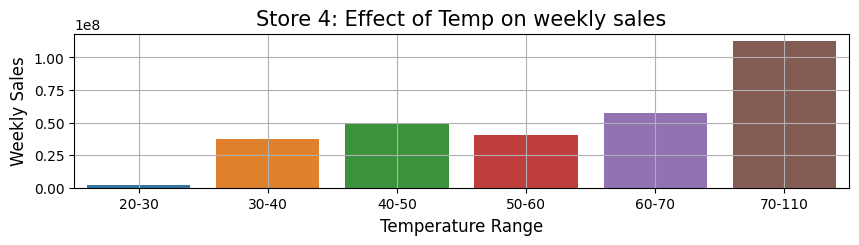

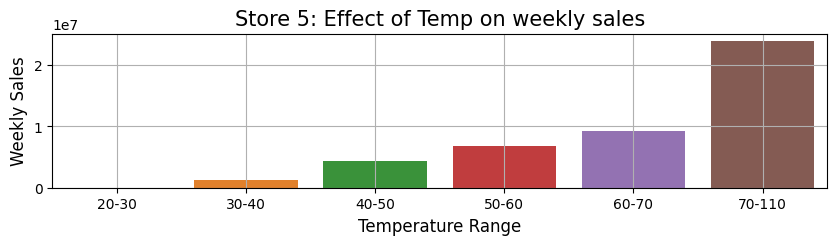

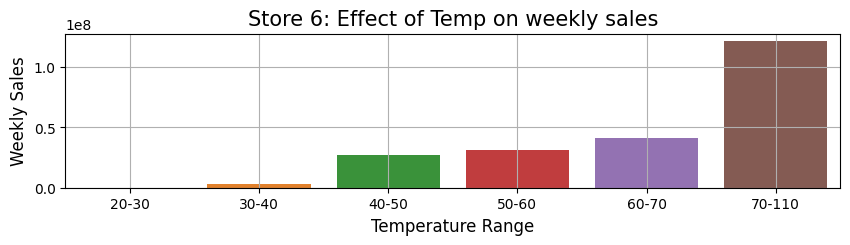

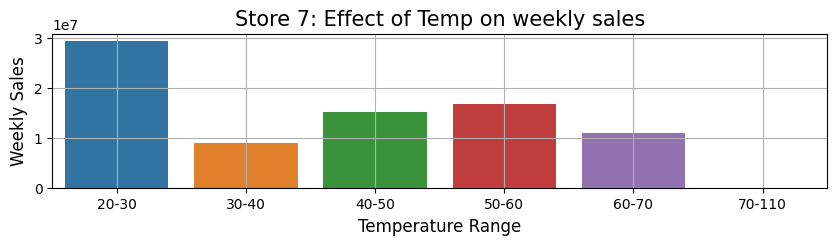

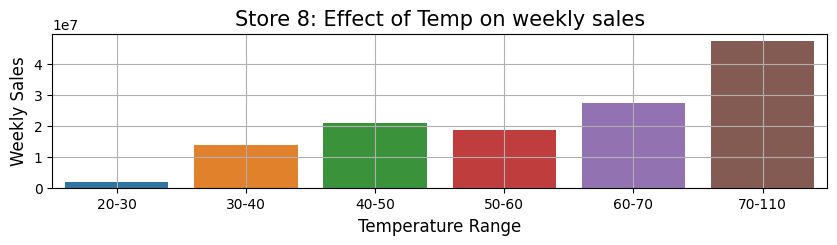

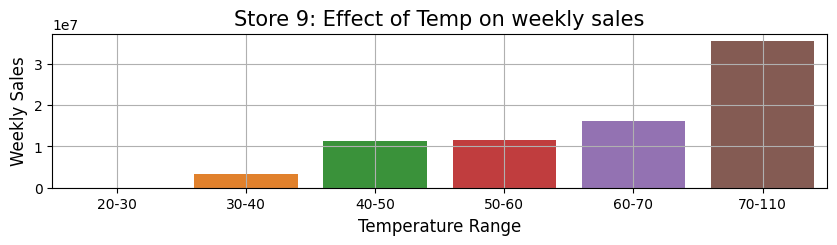

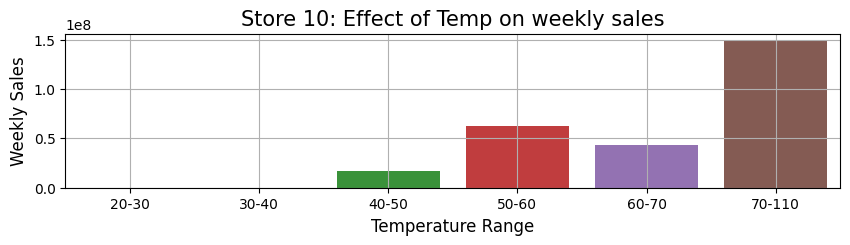

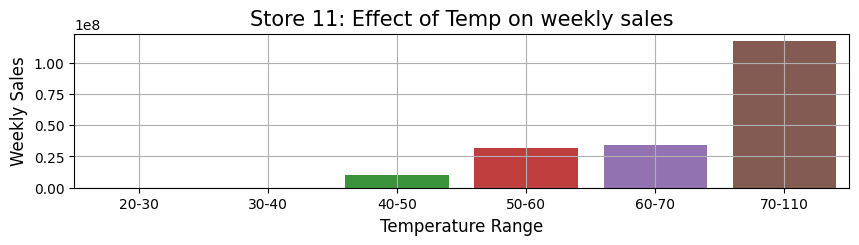

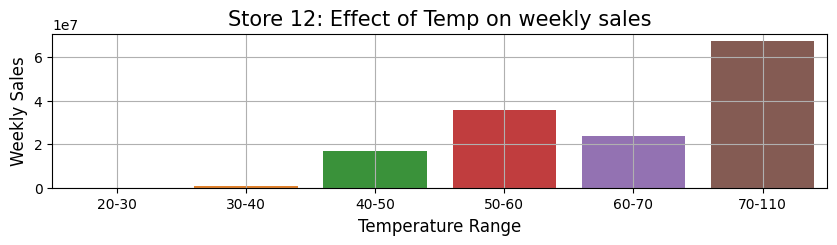

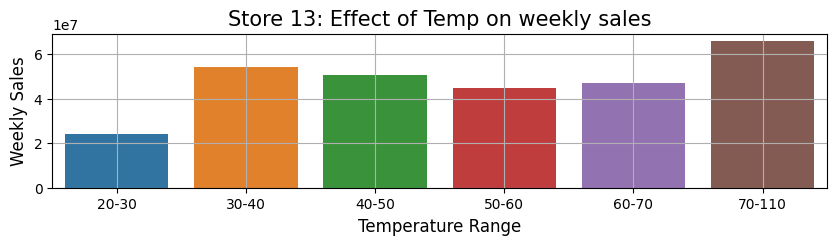

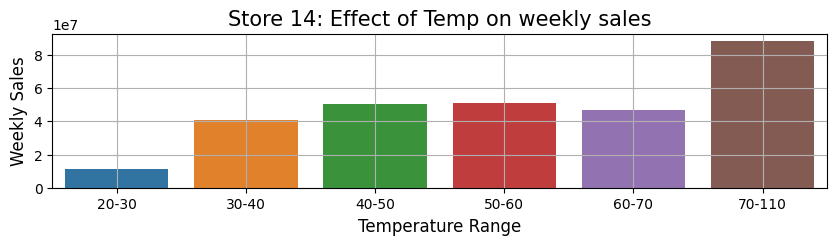

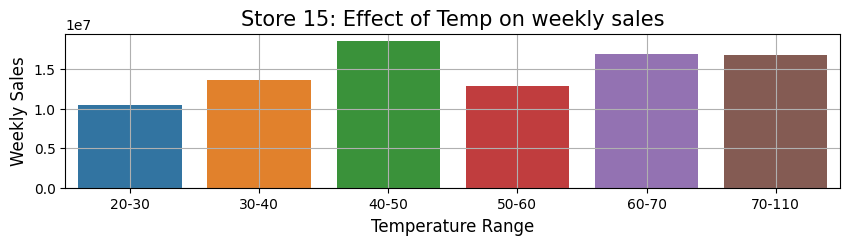

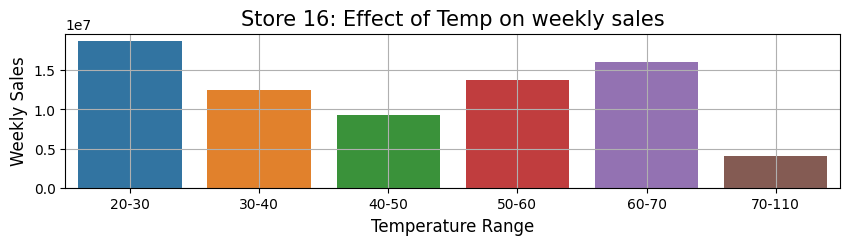

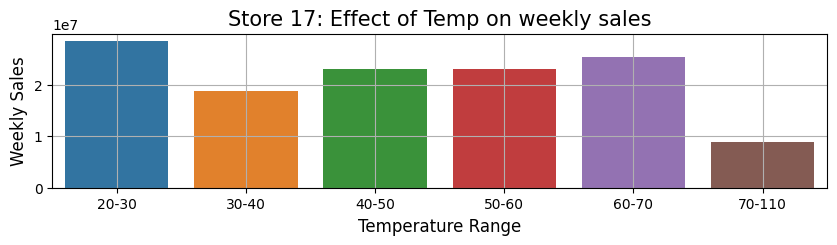

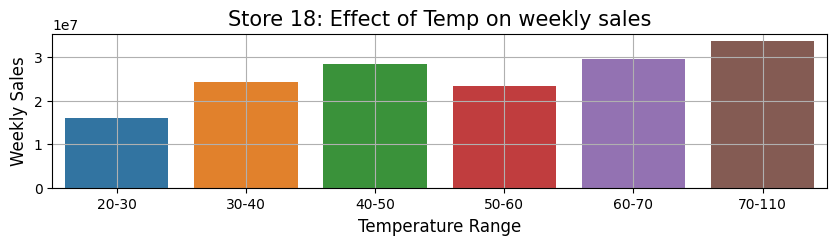

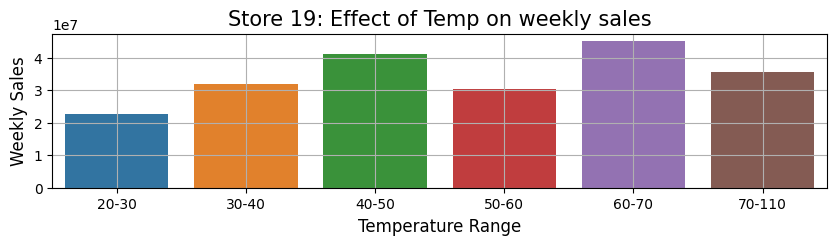

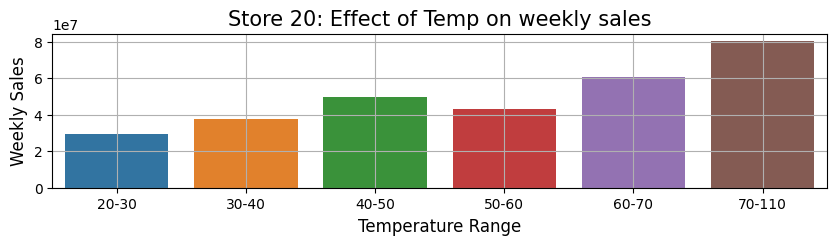

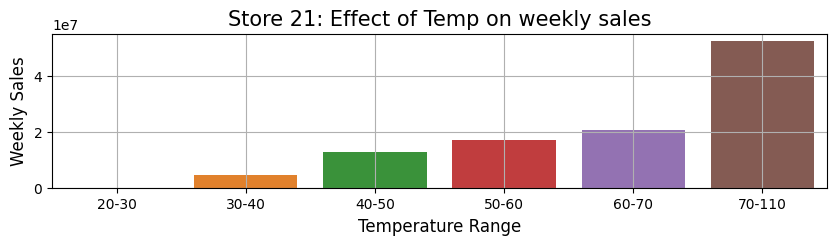

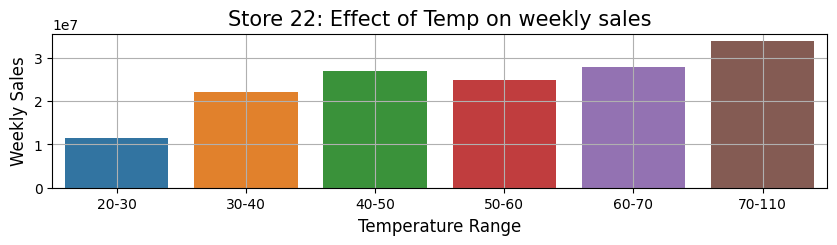

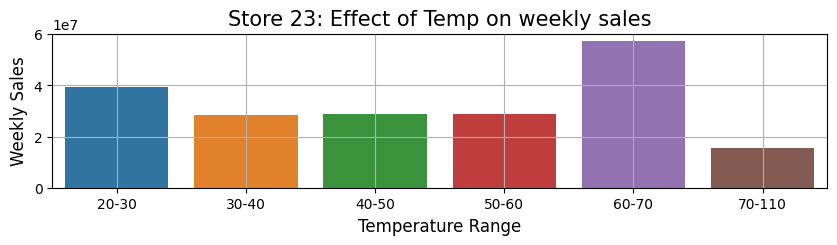

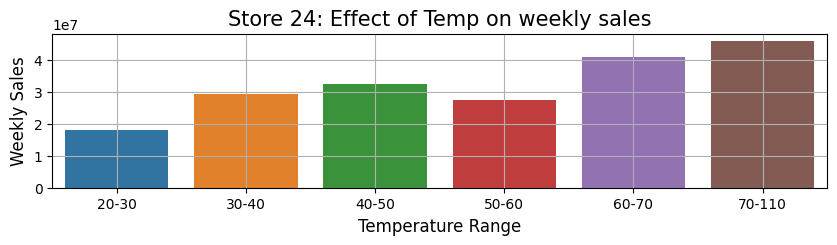

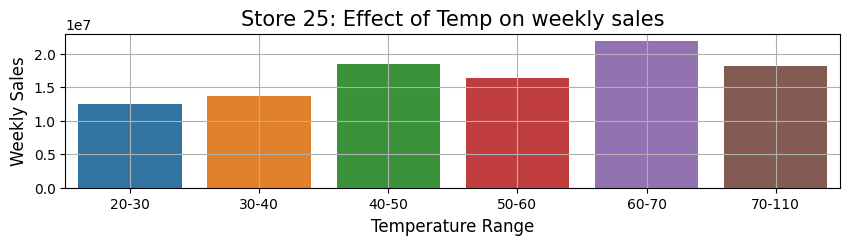

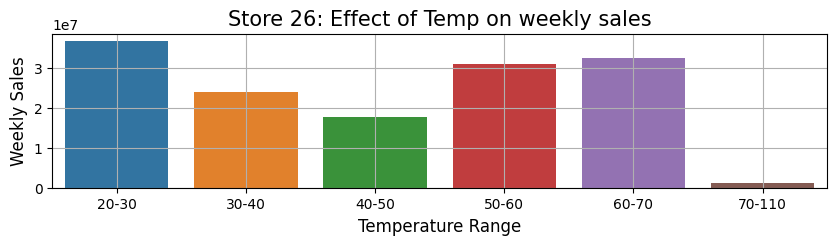

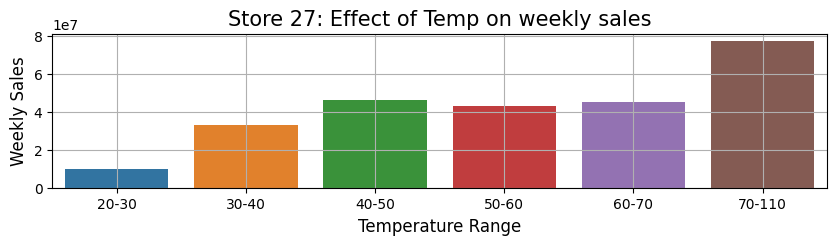

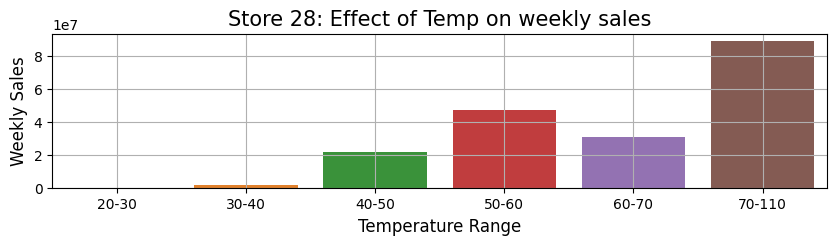

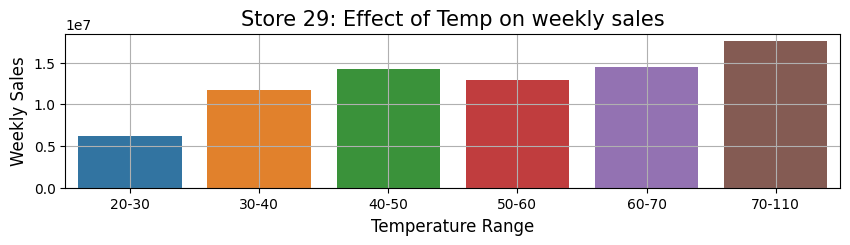

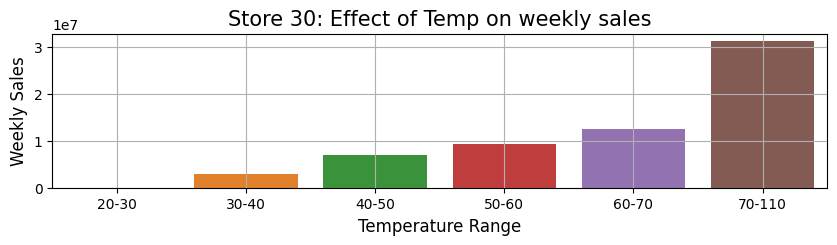

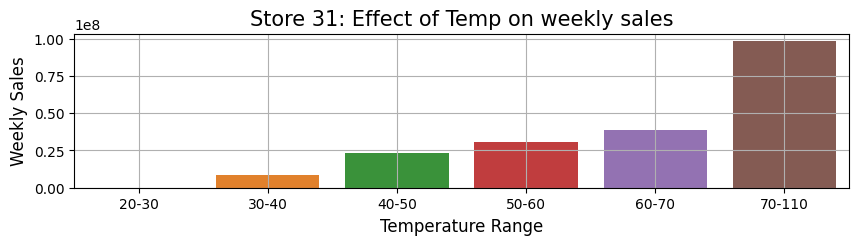

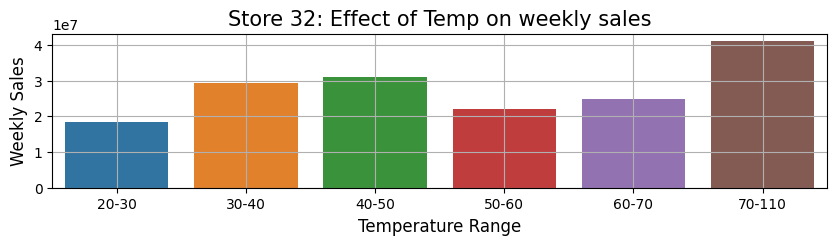

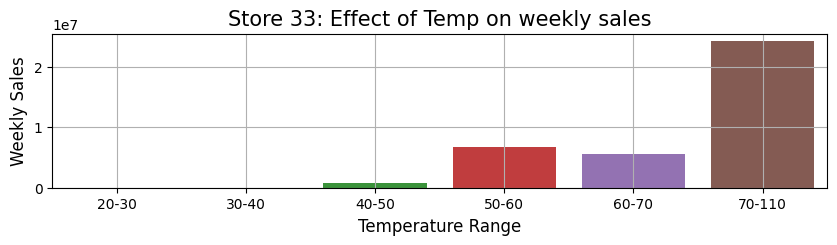

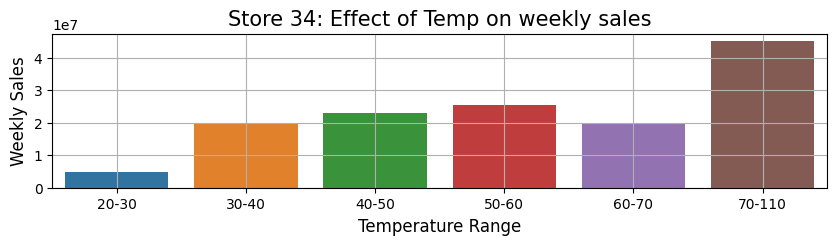

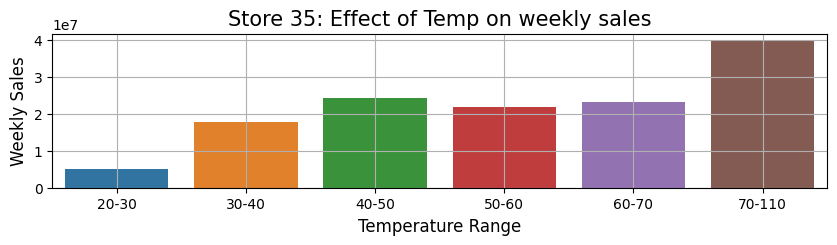

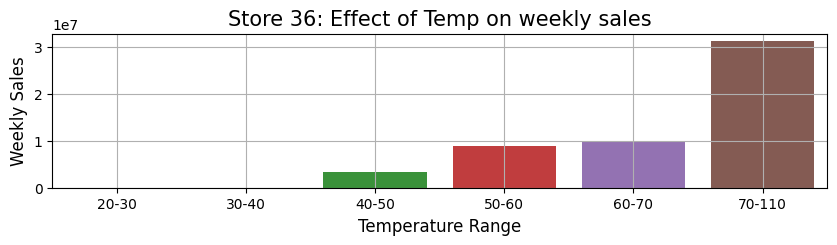

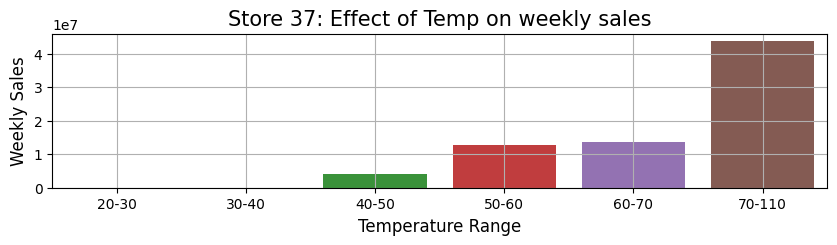

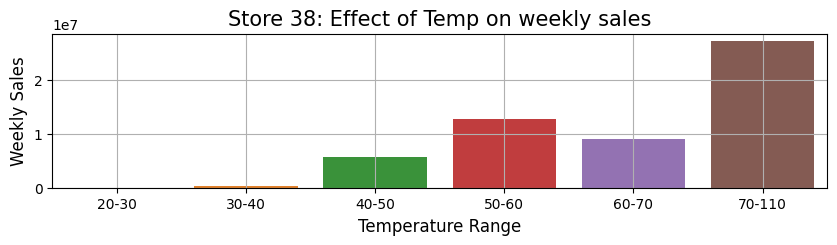

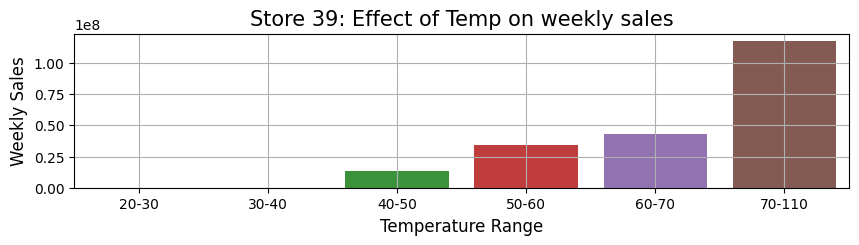

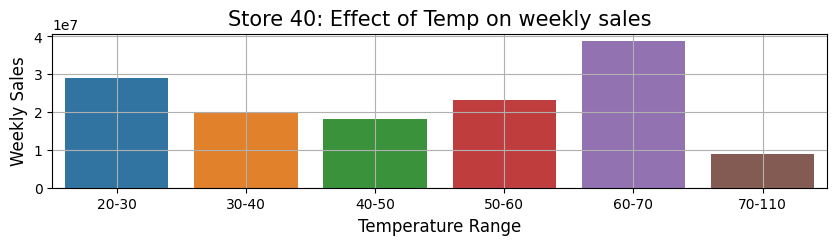

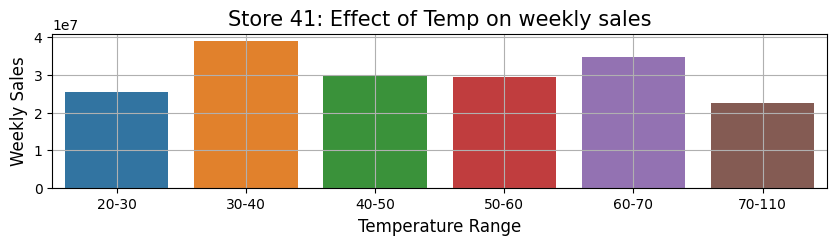

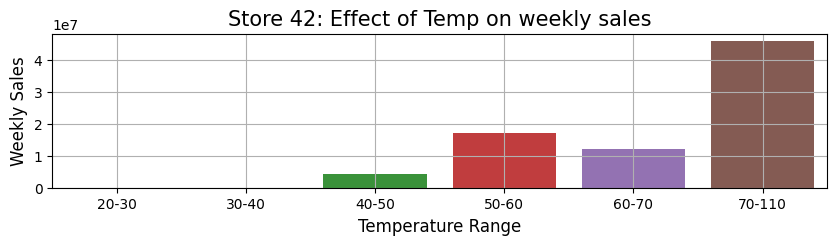

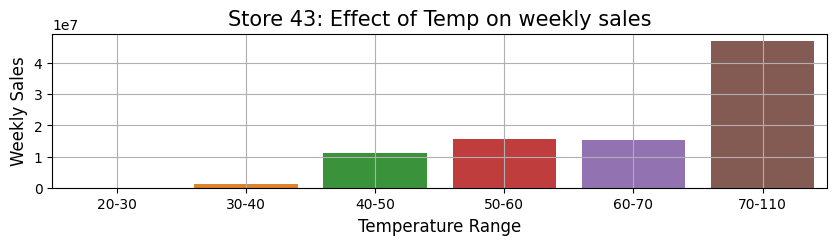

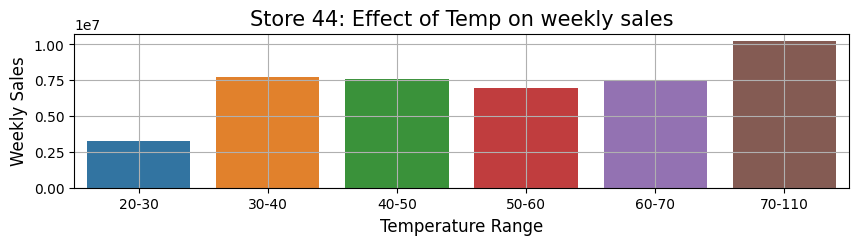

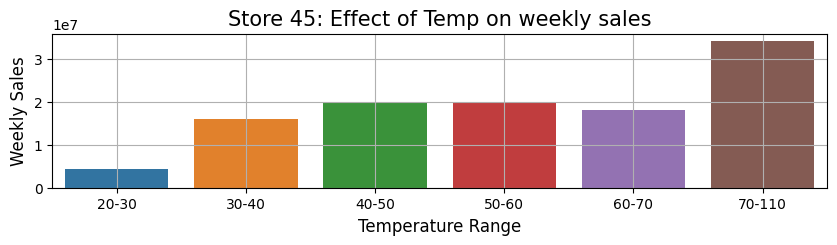

In [38]:
store_list=df['Store'].unique()
for i in store_list:
    x_store=get_store_df(df,'Store',i)
    x_store=x_store[['Store','Temperature','Weekly_Sales']].sort_values('Temperature')
    x_store['Temperature']=pd.cut(x_store['Temperature'], bins=[0,30,40,50,60,70,110],labels=['20-30','30-40','40-50','50-60','60-70','70-110'])
    x_store=x_store.groupby('Temperature')['Weekly_Sales'].sum().reset_index()
    
    fig,axes=plt.subplots(figsize=(10,2))
    sns.barplot(x=x_store.Temperature,y=x_store.Weekly_Sales)
    plt.xlabel("Temperature Range",fontsize=12)
    plt.ylabel("Weekly Sales",fontsize=12)
    plt.title(f"Store {i}: Effect of Temp on weekly sales",fontsize=15)
    plt.grid(True)

In [39]:
from statsmodels.tsa.stattools import adfuller
store_x,store_y=[],[]
p_value_x,p_value_y=[],[]
Test_stat_x,Test_stat_y=[],[]
found_p_value=False
for i in Store_list:
    store_df=get_store_df(df,'Store',i)
    adft=adfuller(store_df['Weekly_Sales'],autolag='AIC')
    Values=[adft[0],adft[1],adft[2],adft[3],adft[4]["1%"],adft[4]["5%"],adft[4]["10%"]]
    p_value=adft[1]
    Test_stat=adft[0]
    if p_value>0.05:
        found_p_value
        store_x.append(i)
        p_value_x.append(p_value)
        Test_stat_x.append(Test_stat)
    else:
        store_y.append(i)
        p_value_y.append(p_value)
        Test_stat_y.append(Test_stat)
        
        
xstores=pd.DataFrame(zip(store_x,p_value_x,Test_stat_x),columns=['Store','p-value','Test Statistics'])
ystores=pd.DataFrame(zip(store_y,p_value_y,Test_stat_y),columns=['Store','p-value','Test Statistics'])

print(f"Non-Stationary TS Stores:\n   Dick Fuller Test Results for p-values greater than 0.05\n {xstores}")
print(f"Stationary TS Stores:\n   Dick Fuller Test Results for p-values smaller than 0.05\n {ystores}")

Non-Stationary TS Stores:
   Dick Fuller Test Results for p-values greater than 0.05
    Store   p-value  Test Statistics
0     14  0.067870        -2.736887
1     43  0.106059        -2.539930
2     42  0.457285        -1.649531
3     30  0.168364        -2.311254
4     38  0.916563        -0.360017
5     36  0.973016         0.213632
6     44  0.759162        -0.983703
Stationary TS Stores:
   Dick Fuller Test Results for p-values smaller than 0.05
     Store       p-value  Test Statistics
0      20  3.491295e-06        -5.393739
1       4  4.779866e-02        -2.879382
2      13  2.056446e-06        -5.502482
3       2  3.990207e-03        -3.708863
4      10  8.763068e-06        -5.200703
5      27  6.821221e-06        -5.253779
6       6  2.159486e-06        -5.492502
7       1  1.387779e-05        -5.102186
8      39  4.783858e-04        -4.281374
9      19  1.161473e-06        -5.618164
10     31  3.060459e-04        -4.392493
11     23  1.772736e-07        -5.988045
12     24  

In [40]:
df_group.head()

,Store,Weekly_Sales
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08
3,13,2.865177e+08
4,2,2.753824e+08


In [41]:
sd=ystores['Store'].tolist()
nsd=xstores['Store'].tolist()

In [42]:
tstores=df_group['Store'].tolist()

In [43]:
print(tstores)

[20, 4, 14, 13, 2, 10, 27, 6, 1, 39, 19, 31, 23, 24, 11, 28, 41, 32, 18, 22, 12, 26, 34, 40, 35, 8, 17, 45, 21, 25, 43, 15, 7, 42, 9, 29, 16, 37, 30, 3, 38, 36, 5, 44, 33]


In [44]:
highest_12_sd=[]
highest_12_sd=sd[0:12]

In [45]:
highest_12_sd

[20, 4, 13, 2, 10, 27, 6, 1, 39, 19, 31, 23]

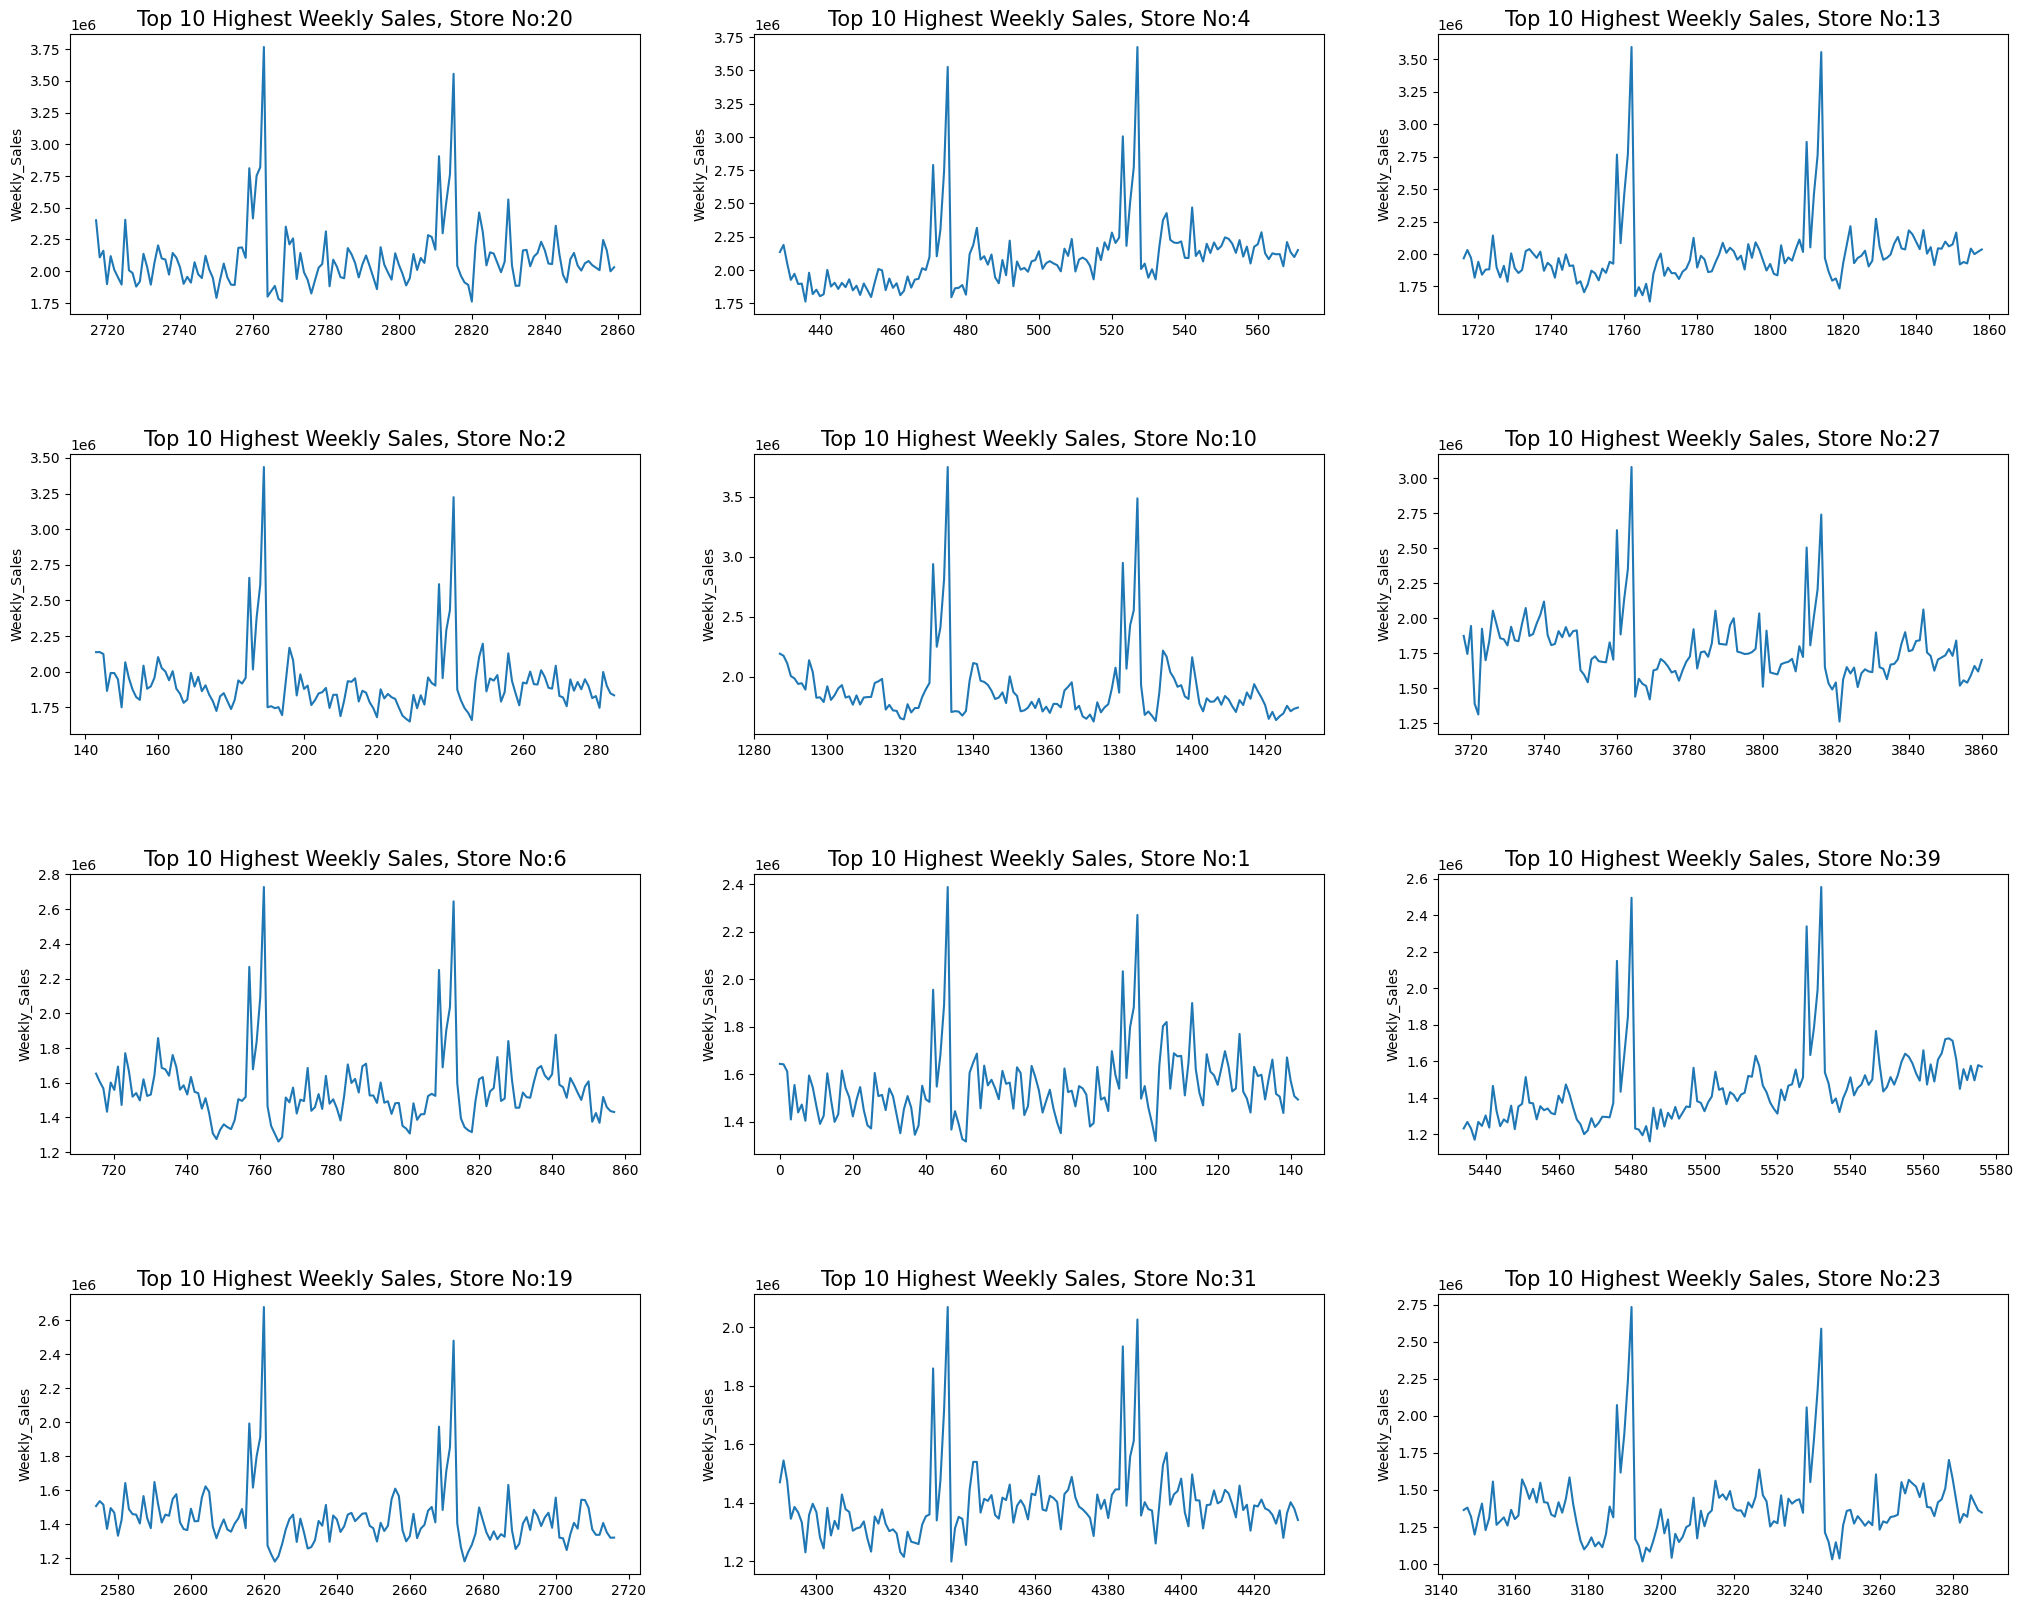

In [46]:
fig,axes=plt.subplots(4,3,figsize=(25,20))
plt.subplots_adjust(hspace=0.5)
j=1
for i in highest_12_sd:
    store_df=get_store_df(df,'Store',i)
    plt.subplot(4,3,j)
    store_df['Weekly_Sales'].plot()
    plt.title("Top 10 Highest Weekly Sales, Store No:"+str(i),fontsize=15)
    plt.ylabel("Weekly_Sales")
    j=j+1

In [51]:
from pmdarima import auto_arima
for i in highest_12_sd:
    print(f"Highest Weekly Sales: Best order for ARIMA model for Store #{i}")
    store_df=get_store_df(df,'Store',i)
    multiple_models=auto_arima(store_df['Weekly_Sales'],trace=True)
    print("\n__________________________________________________________")

Highest Weekly Sales: Best order for ARIMA model for Store #20
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=3974.854, Time=0.51 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=3991.763, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=3971.424, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=3977.707, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4574.703, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=3972.263, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=3972.813, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=3974.255, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.878 seconds

__________________________________________________________
Highest Weekly Sales: Best order for ARIMA model for Store #4
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3941.121, Time=0.29 s

In [52]:
def get_predicitons(actual,predicted):
    predict_dbf=pd.DataFrame(zip(actual,predicted),columns=['Actual','Predicted'])
    predict_dbf['Error(%)']=abs(predict_dbf.Actual-predict_dbf.Predicted)*100/predict_dbf.Actual
    predict_dbf=predict_dbf.sort_values(by=['Error(%)']).reset_index()
    del predict_dbf['index']
    print('\n--------------Predicted Result--------------')
    print(predict_dbf.head(),"\n_________________")
    print(f"Median error:{round(predict_dbf['Error(%)'].median(),2)}%")
    print(f"Mean error:{round(predict_dbf['Error(%)'].mean(),2)}%")
    print("--------------------------\n")
    return(predict_dbf)

In [53]:
from statsmodels.tsa.arima.model import ARIMA
AIRMA_orders=[[1,0,0],[2,0,0],[2,1,3],[5,1,1]]
predictions=list()
Arima_X_train,Arima_X_test=[],[]
test_index_list=[]
train_index_list=[]
for i in highest_12_sd:
    store_df=get_store_df(df,'Store',i)
    store_df=store_df[['Date','Weekly_Sales']]
    store_df.index = store_df['Date']
    del store_df['Date']
    size=int(store_df.shape[0]*0.80)
    train, test=store_df.iloc[:size,:], store_df.iloc[size:,:]
    Arima_X_train.append(train)
    Arima_X_test.append(test)
    train_index=train.index
    test_index=test.index
    Arima_test_index=test.index
    Arima_train_index=train.index
    start_1=train.shape[0]
    end_1=(train.shape[0]+test.shape[0])-1
    Actual_1=test['Weekly_Sales']
    predict_index=Actual_1.index
    Actual_2=Actual_1.tolist()
    if i==2 or i==13 or i==20 or i==6 or i==19 or i==31 or i==23:
        arima=AIRMA_orders[0]
    if i==4 or i==1:
        arima=AIRMA_orders[2]
    if i==10 or i==27:
        arima=AIRMA_orders[1]
    if i==39:
        arima=AIRMA_orders[3]
    print(f"\nResults for store #{i}\n Best Arima order:{arima}")
    model=ARIMA(train['Weekly_Sales'],order=arima)
    model_fit=model.fit()
    print(model_fit.summary())
    
    predicted1=model_fit.predict(start=start_1,end=end_1)
    predicted2=pd.DataFrame()
    predicted2['Weekly_Sales']=predicted1
    predicted2.index=predict_index
    test_index_list.append(test.index)
    train_index_list.append(train.index)
    predictions.append(get_predicitons(Actual_2,predicted1.tolist()))
Arima_predict=predictions


Results for store #20
 Best Arima order:[1, 0, 0]
                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1591.241
Date:                Wed, 10 May 2023   AIC                           3188.483
Time:                        08:37:45   BIC                           3196.692
Sample:                             0   HQIC                          3191.814
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.115e+06   5.73e+04     36.909      0.000       2e+06    2.23e+06
ar.L1          0.3927      0.046      8.558      0.000       0.303       0.483
s

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsm

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -1572.056
Date:                Wed, 10 May 2023   AIC                           3156.112
Time:                        08:37:46   BIC                           3172.476
Sample:                             0   HQIC                          3162.752
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7881      0.188     -4.184      0.000      -1.157      -0.419
ar.L2         -0.3304      0.199     -1.659      0.097      -0.721       0.060
ma.L1          0.3340      0.174      1.914      0.0

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages


--------------Predicted Result--------------
       Actual     Predicted  Error(%)
0  1939440.09  1.930212e+06  0.475790
1  1974687.51  2.010422e+06  1.809644
2  1880436.94  1.930203e+06  2.646492
3  1869967.03  1.930257e+06  3.224104
4  1840491.41  1.931711e+06  4.956280 
_________________
Median error:9.35%
Mean error:9.18%
--------------------------


Results for store #27
 Best Arima order:[2, 0, 0]
                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1573.994
Date:                Wed, 10 May 2023   AIC                           3155.987
Time:                        08:37:46   BIC                           3166.932
Sample:                             0   HQIC                          3160.429
                                - 114                                         
Covariance Type:                  opg  

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsm

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -1519.892
Date:                Wed, 10 May 2023   AIC                           3051.783
Time:                        08:37:46   BIC                           3068.147
Sample:                             0   HQIC                          3058.424
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7400      0.163     -4.539      0.000      -1.060      -0.421
ar.L2         -0.2902      0.159     -1.829      0.067      -0.601       0.021
ma.L1          0.3069      0.158      1.946      0.0

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(5, 1, 1)   Log Likelihood               -1537.331
Date:                Wed, 10 May 2023   AIC                           3088.662
Time:                        08:37:47   BIC                           3107.754
Sample:                             0   HQIC                          3096.409
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4915      0.114      4.293      0.000       0.267       0.716
ar.L2          0.0580      0.086      0.676      0.499      -0.110       0.226
ar.L3          0.0031      0.085      0.037      0.9

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages

In [54]:
def plot_predictions(predictions,name,store_no):
    fig,axes=plt.subplots(figsize=(20,6))
    sns.lineplot(x=predictions.index,y=predictions['Actual'],color='red',legend=True)
    sns.lineplot(x=predictions.index,y=predictions['Predicted'],color='blue',legend=True)
    plt.title(f"STORE NO: {store_no} ------> {name} Predictions", fontsize=25)
    plt.xlabel("Date",fontsize=15)
    plt.ylabel("Weekly Sales",fontsize=15)
    plt.legend(['Actual','Predicted'],loc='best')
    plt.grid(True)
    plt.show()

In [55]:
def plot_ts_results(predict_df,df_index,model,l=6,w=2,wl=20,ww=10,hs=1.5):
    fig,axes=plt.subplots(l,w,figsize=(wl,ww))
    plt.subplots_adjust(hspace=hs)
    for i in range(len(predict_df)):
        store_df=predict_df[i]
        plt.subplot(l,w,i+1)
        sns.lineplot(x=store_df.index,y=store_df.Actual)
        sns.lineplot(x=store_df.index,y=store_df.Predicted)
        plt.title(f"{model}: Prediction Plot for store{highest_12_sd[i]}",fontsize=25)
        plt.xlabel('Dates')
        plt.ylabel("Predicted Weekly Sales")
        plt.legend(['Actual','Predicted'],loc='best')
        plt.grid(True)

In [56]:
test_index_list[0]

DatetimeIndex(['2012-04-13', '2012-04-20', '2012-04-27', '2012-04-05',
               '2012-11-05', '2012-05-18', '2012-05-25', '2012-01-06',
               '2012-08-06', '2012-06-15', '2012-06-22', '2012-06-29',
               '2012-06-07', '2012-07-13', '2012-07-20', '2012-07-27',
               '2012-03-08', '2012-10-08', '2012-08-17', '2012-08-24',
               '2012-08-31', '2012-07-09', '2012-09-14', '2012-09-21',
               '2012-09-28', '2012-05-10', '2012-12-10', '2012-10-19',
               '2012-10-26'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [57]:
Predictions=list()
for i in range(len(predictions)):
    predictions[i].index=test_index_list[i]
    Predictions.append(predictions[i][['Actual','Predicted','Error(%)']])

In [58]:
Predictions[0].head(10)

,Actual,Predicted,Error(%)
Date,,,
2012-04-13,2114989.00,2.115621e+06,0.029899
2012-04-20,2134680.12,2.114974e+06,0.923133
2012-04-27,2094515.71,2.114973e+06,0.976722
2012-04-05,2143126.59,2.115228e+06,1.301783
2012-11-05,2144245.39,2.114973e+06,1.365148
2012-05-18,2080529.06,2.114973e+06,1.655550
2012-05-25,2163510.89,2.125678e+06,1.748681
2012-01-06,2162951.36,2.114973e+06,2.218178
2012-08-06,2168097.11,2.119177e+06,2.256379


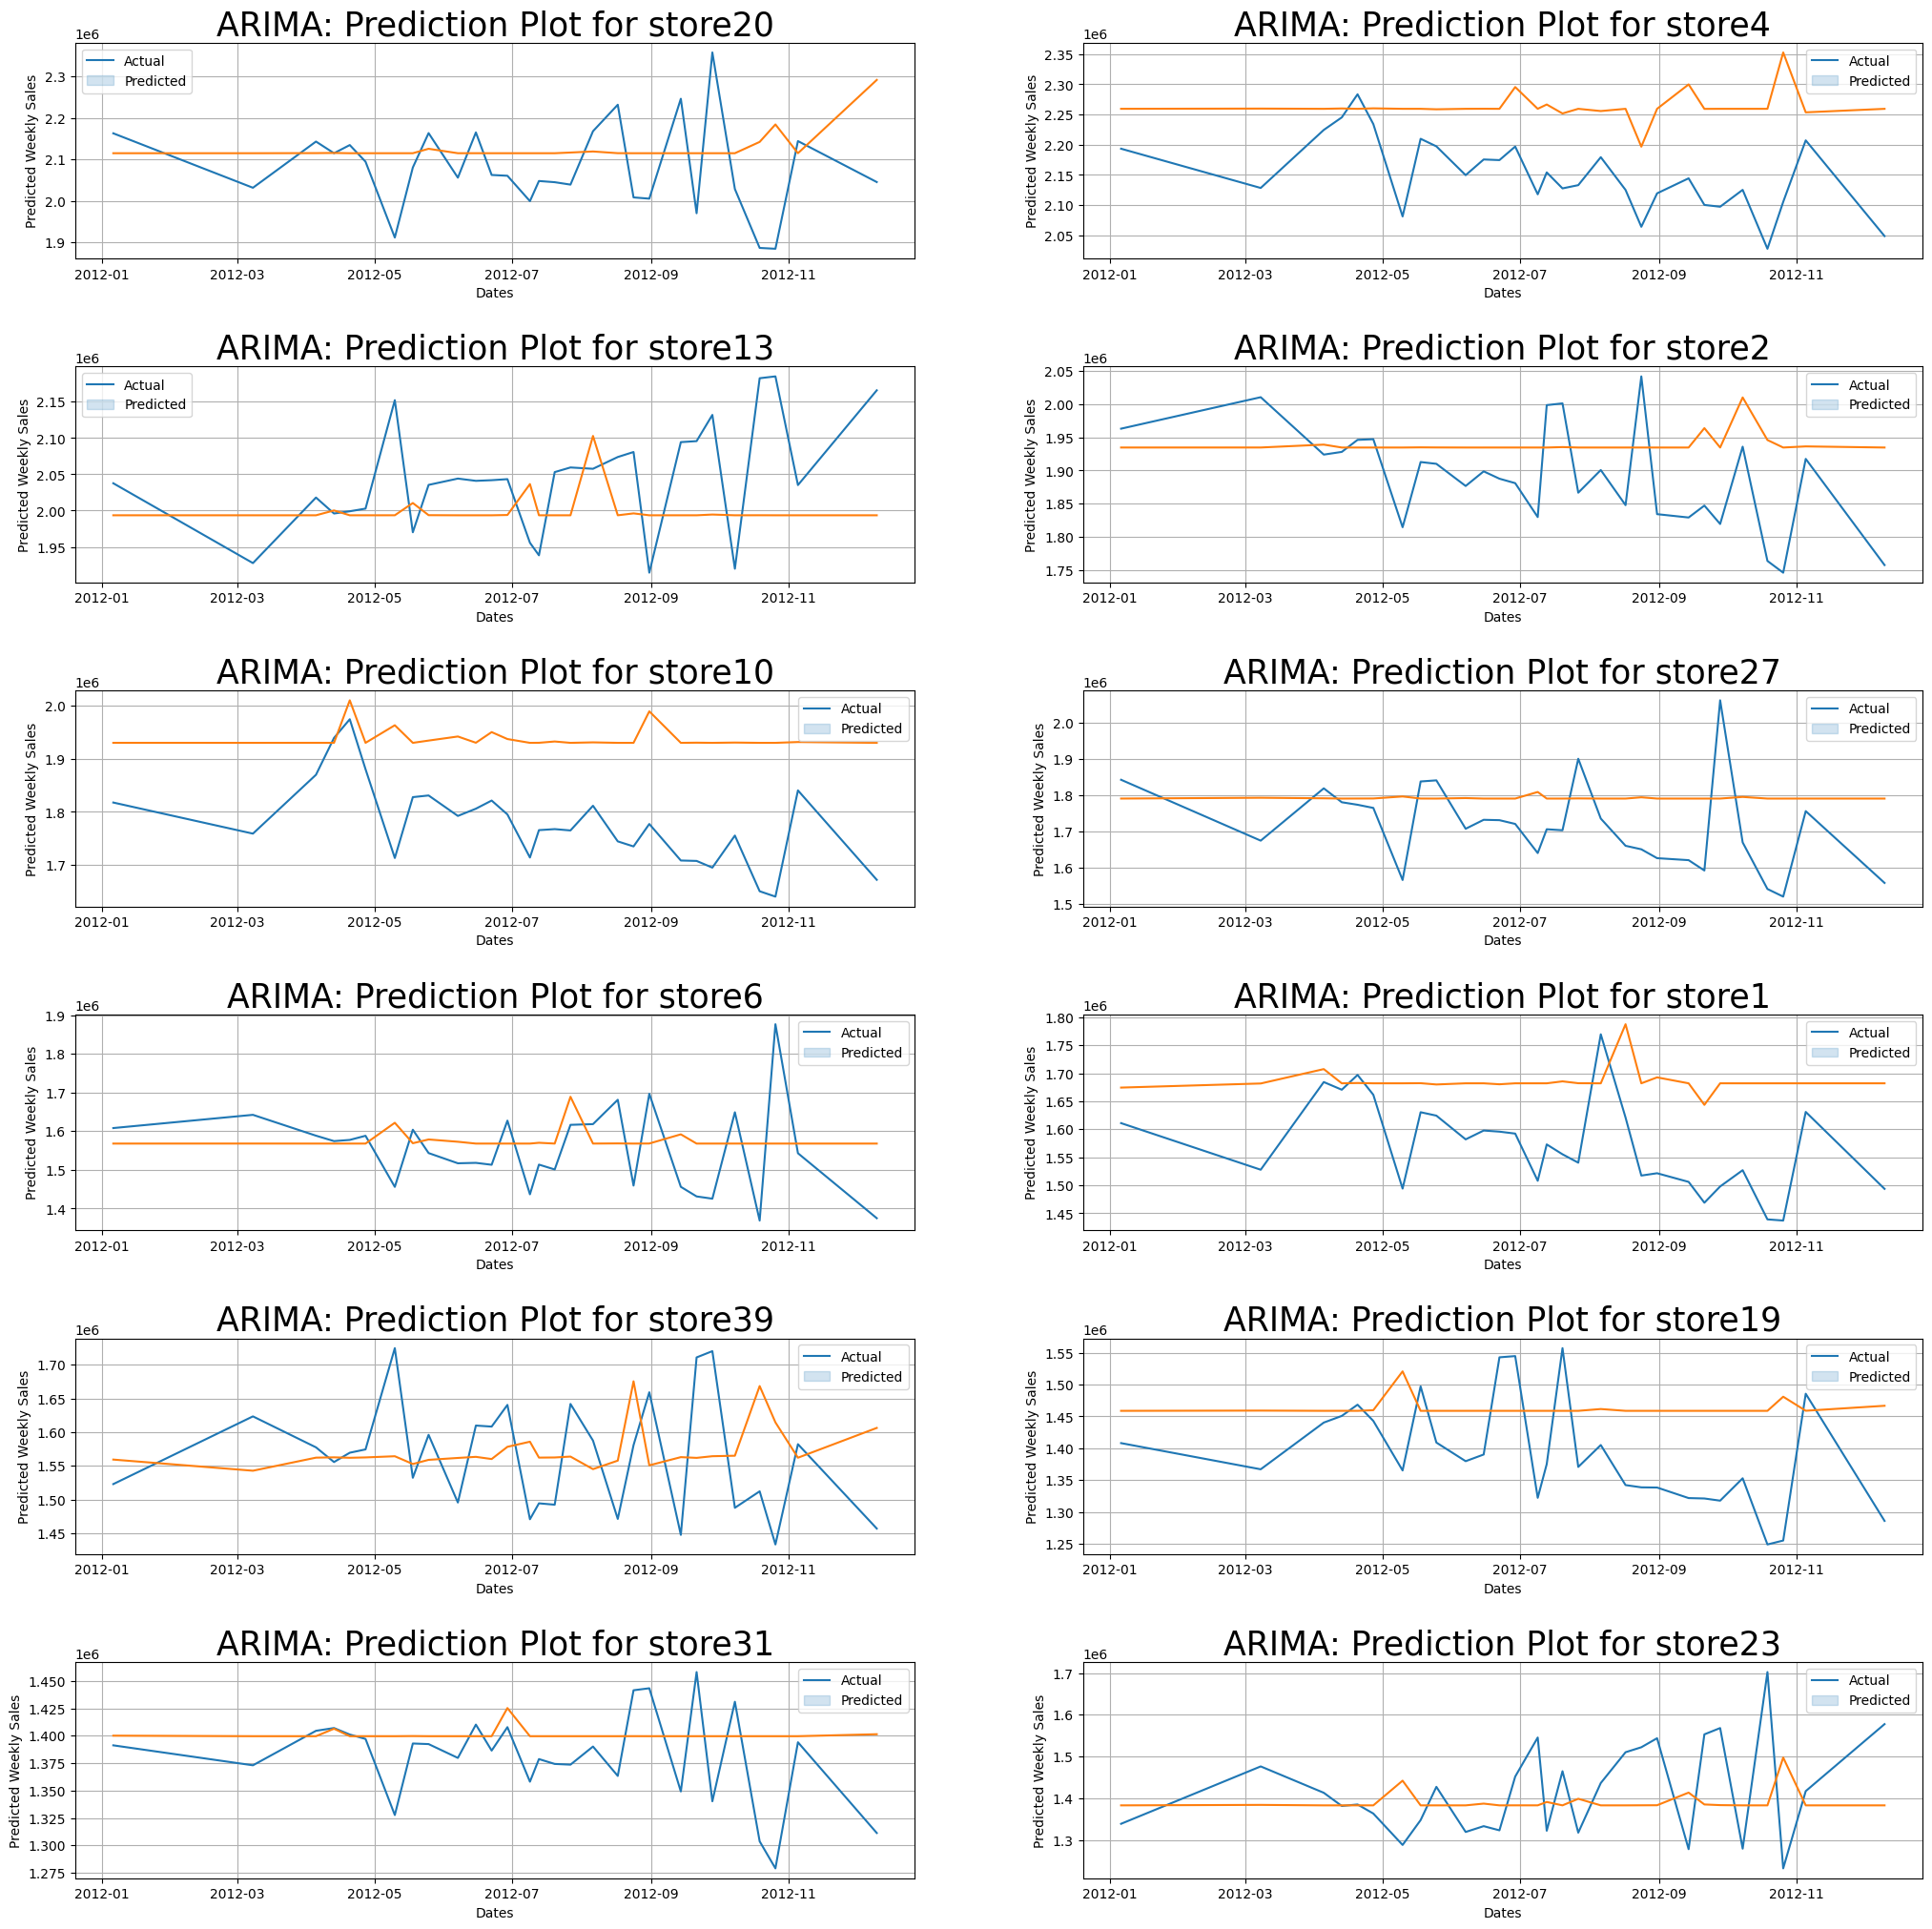

In [59]:
plot_ts_results(Predictions,test_index,'ARIMA',6,2,25,25,.5)